/var/folders/fm/j5zsv9x1121cqbb30njg041r0000gn/T/ipykernel_34907/410787500.py:36: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  S_integral_num = cumtrapz(S, x, initial=0)


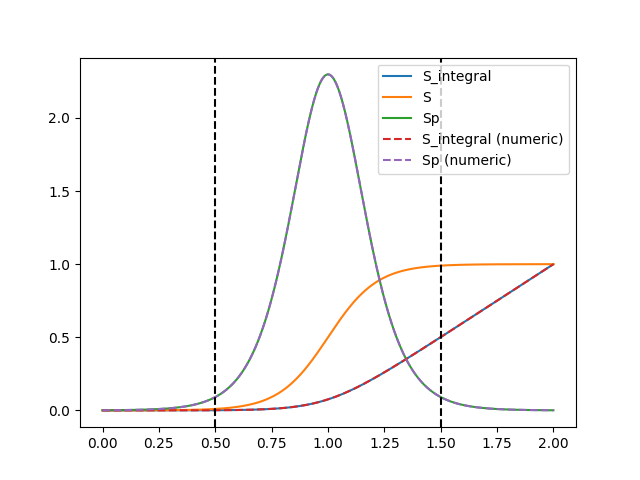

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import expit  # numerically stable sigmoid
import matplotlib.pyplot as plt
%matplotlib widget

# diffentiable step function
def logistic_step(x, x0=0.0, transition_width=0.1, transition_proportion=0.1):
    p = transition_proportion
    k = 2*np.log((1-p)/p) / transition_width
    S = expit(k * (np.asarray(x) - x0))
    Sp = k * S * (1.0 - S)
    Spp = k**2 * S * (1.0 - S) * (1.0 - 2.0 * S)
    S_integral = np.logaddexp(0.0, k * (np.asarray(x) - x0)) / k
    return S_integral, S, Sp, Spp

# Example:
x = np.linspace(0, 2, 1000)
x0 = 1
transition_width = 1
transition_proportion = 0.01
S_integral, S, Sp, Spp = logistic_step(x, x0=x0, transition_width=transition_width, transition_proportion=transition_proportion)

plt.figure()
plt.plot(x,S_integral, label='S_integral')
plt.plot(x,S, label='S')
plt.plot(x,Sp, label='Sp')
# Numerically integrate and differentiate S and plot to compare against analytic

from scipy.integrate import cumtrapz

# S is already given above

# Numerically integrate S (should match S_integral, up to constant)
dx = x[1] - x[0]
S_integral_num = cumtrapz(S, x, initial=0)
S_integral_num += S_integral[0] - S_integral_num[0]  # align initial value

plt.plot(x, S_integral_num, '--', label='S_integral (numeric)')

# Numerically differentiate S (should match Sp)
Sp_num = np.gradient(S, dx)
plt.plot(x, Sp_num, '--', label='Sp (numeric)')


# plt.plot(x,Spp, label='Spp')
plt.legend()
plt.axvline(x=x0+transition_width/2, color='k', linestyle='--')
plt.axvline(x=x0-transition_width/2, color='k', linestyle='--')

pulley: 5.79722
tsa: 7.96762
const_speed: 7.28406


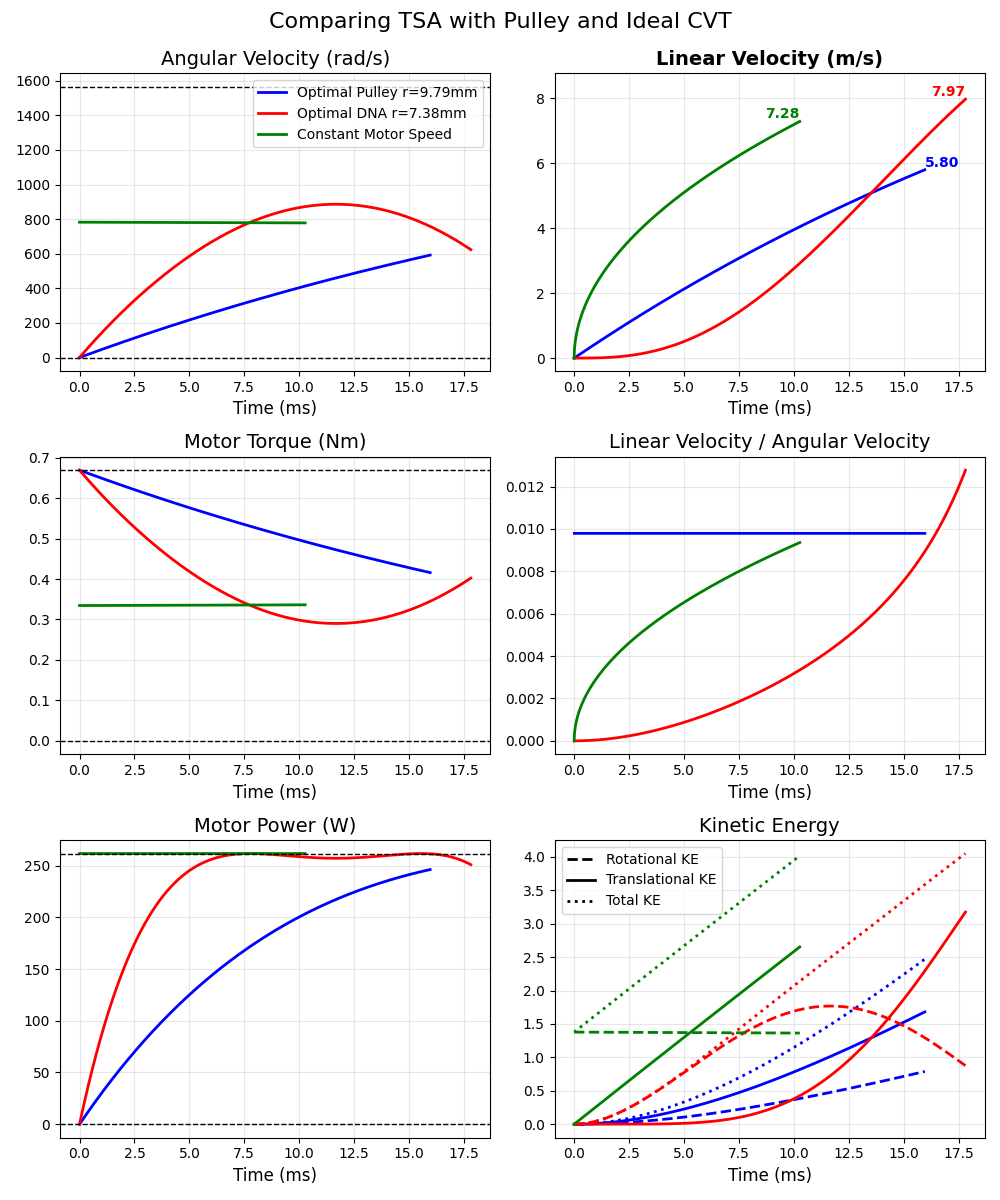

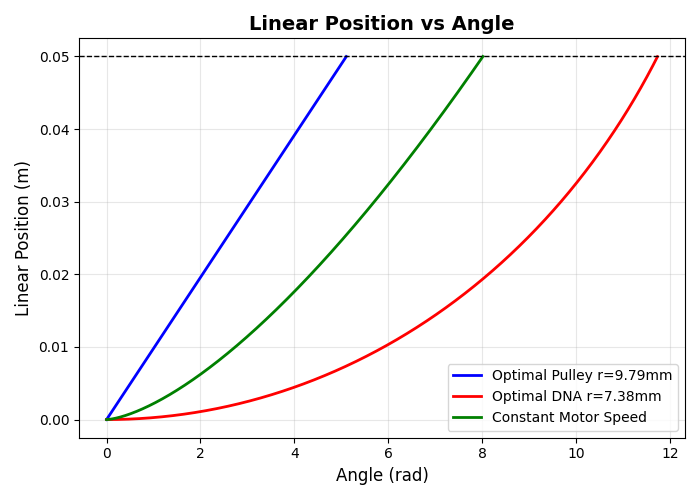

In [6]:

# numerical CVT integration
def integrate_theta(get_y, get_tau, params, theta0=0, theta_dot0=0):

    m = params['m']
    I = params['I']
    stroke = params['stroke']
    g = params['g']
   
    def dynamics(t, state):
        theta, theta_dot = state
        
        y, dy_dtheta, d2y_dtheta2 = get_y(theta)
        tau = get_tau(theta, theta_dot, t)
        
        theta_ddot = (-theta_dot**2 * m * dy_dtheta * d2y_dtheta2 -  m*g*dy_dtheta + tau) / (I + m * (dy_dtheta)**2)
        return [theta_dot, theta_ddot]
    
    # Event function: stop when y reaches stroke
    def y_target_event(t, state):
        theta, theta_dot = state
        y, _, _ = get_y(theta)
        return y - stroke
    
    y_target_event.terminal = True  # Stop integration when event occurs
    y_target_event.direction = 0    # Trigger on both increasing and decreasing
    

    t_max = 2.0
    t_eval = np.arange(0, t_max, 0.00001)
    
    sol = solve_ivp(
        dynamics,
        t_span=(0, t_max),
        y0=[theta0, theta_dot0],
        # method='BDF',  # Can also try 'DOP853', 'Radau', 'BDF'
        method='RK45',
        max_step=5e-6,
        t_eval=t_eval,
        events=y_target_event,
        dense_output=True,
        rtol=1e-6,
        atol=1e-9,
    )
    
    t = sol.t
    theta = sol.y[0]
    theta_d = sol.y[1]
    
    y = np.zeros_like(theta)
    y_d = np.zeros_like(theta)
    tau = np.zeros_like(theta)
    for i, (th, th_d) in enumerate(zip(theta, theta_d)):
        y_val, dy_dtheta, _ = get_y(th)
        y[i] = y_val
        y_d[i] = dy_dtheta * th_d  # Chain rule: dy/dt = (dy/dtheta) * (dtheta/dt)
        tau[i] = get_tau(th, th_d, t[i])
    
    return {
        't': t,
        'theta': theta,
        'theta_d': theta_d,
        'y': y,
        'y_d': y_d,
        'tau': tau,
    }

voltage_base = 7
params = {
    'm': 0.100, # mass
    # 'I': 0.5 * (37.4/1000/2) * (28.4/1000/2)**2,  #kg m^2
    'I': 4.5e-6,  #kg m^2
    'stroke': 0.050, # y starts from zero and stops at stroke
    # 'g': 9.81, #m/s^2
    'g': 9.81, #m/s^2
    # 'tau_max': 0.2795, #Nm
    # 'w_max': 1704, #rad/s
    'tau_max': 0.09555555556 * voltage_base, #Nm
    'w_max': 2135*2*np.pi/60 * voltage_base, #rad/s
}

def get_tau(theta, theta_dot, t):
    return params['tau_max']*(1 - theta_dot/params['w_max'])

r_pulley = 0.00979
def get_y_pulley(theta):
    y = r_pulley * theta
    dy_dtheta = r_pulley
    d2y_dtheta2 = 0
    return y, dy_dtheta, d2y_dtheta2
res_pulley = integrate_theta(get_y_pulley, get_tau, params)


L = 0.100
y_offset = 0.000 # L - y_offset > stroke
offset_direction = 1 # 1 for forward, -1 for backward
r = 0.00738
theta_offset = offset_direction * np.sqrt(L**2 - (L - y_offset)**2) / r
def get_y_tsa(theta):
    y = L - np.sqrt(L**2 - (r*theta)**2)
    dy_dtheta =  (r**2 * theta) / np.sqrt(L**2 - (r*theta)**2)
    d2y_dtheta2 =  (r**2 * L**2) / (L**2 - (r*theta)**2)**(3/2)
    return y, dy_dtheta, d2y_dtheta2
res_tsa = integrate_theta(get_y_tsa, get_tau, params, theta0=theta_offset, theta_dot0=0)

y_offset = 0.005 # L - y_offset > stroke
offset_direction = -1 # 1 for forward, -1 for backward
theta_offset = offset_direction * np.sqrt(L**2 - (L - y_offset)**2) / r
res_tsa_prewind = integrate_theta(get_y_tsa, get_tau, params, theta0=theta_offset, theta_dot0=0)

def get_y_const_speed(theta):
    P_max = params['tau_max']*params['w_max'] / 4
    m = params['m']
    w_max = params['w_max']
    w_opt = w_max/2

    A = (2/3) * np.sqrt(2*P_max/m)

    y = A * (theta/w_opt)**(3/2)
    dy_dtheta = A * (3/2) * (theta/w_opt)**(1/2) * (1/w_opt)

    if theta > 1e-6:
        d2y_dtheta2 = A * (3/2) * (1/2) * (theta/w_opt)**(-1/2) * (1/w_opt)**2
    else:
        d2y_dtheta2 = A * (3/2) * (1/2) * (theta/w_opt+1e-6)**(-1/2) * (1/w_opt)**2
    return y, dy_dtheta, d2y_dtheta2
res_const_speed = integrate_theta(get_y_const_speed, get_tau, params, theta0=0, theta_dot0=params['w_max']/2)

transition_width = 30
clutch_r = 0.1
def get_y_clutch(theta):
    S_integral, S, Sp, Spp = logistic_step(theta, x0=60.0, transition_width=transition_width, transition_proportion=0.01)
    r = clutch_r
    y = r*S_integral
    dy_dtheta = r*S
    d2y_dtheta2 = r*Sp
    return y, dy_dtheta, d2y_dtheta2
no_torque = lambda theta, theta_dot, t: 0
# res_clutch = integrate_theta(get_y_clutch, get_tau=no_torque, params=params, theta0=0, theta_dot0=params['w_max'])
res_clutch = integrate_theta(get_y_clutch, get_tau=get_tau, params=params, theta0=0, theta_dot0=0)

transition_width = 0.1
# clutch_r = 0.015
# clutch_r = 0.0072
clutch_r = 10
# res_clutch_hard = integrate_theta(get_y_clutch, get_tau=no_torque, params=params, theta0=0, theta_dot0=params['w_max'])
res_clutch_hard = integrate_theta(get_y_clutch, get_tau=get_tau, params=params, theta0=0, theta_dot0=0)

#Plotting
if True:
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    axes = axes.flatten()

    res_all = {
        'pulley': res_pulley,
        'tsa': res_tsa,
        # 'tsa_prewind': res_tsa_prewind,
        'const_speed': res_const_speed,
        # 'clutch': res_clutch,
        # 'clutch_hard': res_clutch_hard,
    }


    colors = {
        'pulley': 'b', 
        'tsa': 'r', 
        'tsa_prewind': 'orange', 
        'const_speed': 'g', 
        'clutch': 'purple',
        'clutch_hard': 'magenta',
    }
    labels = {
        'pulley': f'Optimal Pulley r={r_pulley*1000:.2f}mm', 
        'tsa': f'Optimal DNA r={r*1000:.2f}mm', 
        'const_speed': 'Constant Motor Speed', 
        'tsa_prewind': 'TSA Prewind', 
        'clutch': 'Soft Clutch',
        'clutch_hard': 'Hard Clutch',
    }
    title = 'Comparing TSA with Pulley and Ideal CVT'
    fig.suptitle(title, fontsize=16, y=0.99)

    # # theta vs t
    # for key, res in res_all.items():
    #     axes[0].plot(res['t'], res['theta'], color=colors[key], linewidth=2, label=labels[key])
    # # axes[0].set_ylabel('Angle (rad)', fontsize=12)
    # axes[0].set_xlabel('Time (s)', fontsize=12)
    # axes[0].grid(True, alpha=0.3)
    # axes[0].set_title('Angle (rad)', fontsize=14)
    # axes[0].legend()

    # theta_dot vs t
    # Use time in milliseconds for all time plots
    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000  # convert to ms
        axes[0].plot(t_ms, res['theta_d'], color=colors[key], linewidth=2, label=labels[key])
    # axes[1].set_ylabel('Angular Velocity (rad/s)', fontsize=12)
    axes[0].set_xlabel('Time (ms)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Angular Velocity (rad/s)', fontsize=14)
    axes[0].axhline(y=0, color='k', linestyle='--', linewidth=1)
    axes[0].axhline(y=params['w_max'], color='k', linestyle='--', linewidth=1)
    axes[0].legend()

    # # y vs t
    # for key, res in res_all.items():
    #     t_ms = np.array(res['t']) * 1000
    #     axes[2].plot(t_ms, res['y'], color=colors[key], linewidth=2, label=labels[key])
    # # axes[2].set_ylabel('Linear Position (m)', fontsize=12)
    # axes[2].set_xlabel('Time (ms)', fontsize=12)
    # axes[2].grid(True, alpha=0.3)
    # axes[2].set_title('Linear Position (m)', fontsize=14)

    # y_dot vs t
    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000
        axes[1].plot(t_ms, res['y_d'], color=colors[key], linewidth=2, label=labels[key])
        # Mark the final point in y_dot vs t for each key
        final_y_d = res['y_d'][-1]
        print(f"{key}: {final_y_d:.5f}")
        if key == 'pulley':
            axes[1].text(
                t_ms[-1],
                final_y_d,
                f"{final_y_d:.2f}",
                fontsize=10,
                color=colors[key],
                va='bottom',
                ha='left',
                fontweight='bold'
            )
        else:
            axes[1].text(
                t_ms[-1],
                final_y_d,
                f"{final_y_d:.2f}",
                fontsize=10,
                color=colors[key],
                va='bottom',
                ha='right',
                fontweight='bold'
            )
        if key == 'clutch' or key == 'tsa':
            axes[1].set_ylim(None, final_y_d*1.1)
    # axes[3].set_ylabel('Linear Velocity (m/s)', fontsize=12)
    axes[1].set_xlabel('Time (ms)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('Linear Velocity (m/s)', fontsize=14, fontweight='bold')
    # axes[3].set_ylim(0, 8)


    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000
        # KE = 0.5 * I * theta_dot^2
        # Assume moment of inertia I=1 for demonstration. Replace with actual if available.
        I = params['I']
        m = params['m']
        KE_rot = 0.5 * I * np.array(res['theta_d'])**2
        KE_trans = 0.5 * m * np.array(res['y_d'])**2
        axes[5].plot(t_ms, KE_rot, color=colors[key], linestyle='--', linewidth=2, label=f"{labels[key]} Rotational")
        axes[5].plot(t_ms, KE_trans, color=colors[key], linewidth=2, label=f"{labels[key]} Translational")
        axes[5].plot(t_ms, KE_rot + KE_trans, linestyle=':', color=colors[key], linewidth=2, label=f"{labels[key]} Total")

        tau = np.array(res['tau'])        # Torque
        theta_d = np.array(res['theta_d'])  # Angular velocity
        power = tau * theta_d             # Power = torque * angular speed

        # Compute total kinetic energy = rotational + translational
        KE_rot = 0.5 * params['I'] * theta_d**2
        y_d = np.array(res['y_d'])
        KE_trans = 0.5 * params['m'] * y_d**2
        KE_total = KE_rot + KE_trans

        # Compute d(KE_total)/dt numerically
        t = np.array(res['t'])
        t_ms_local = t * 1000
        dKE_dt = np.gradient(KE_total, t)

        # Plot power (tau*theta_d)
        axes[4].plot(t_ms_local, power, color=colors[key], linewidth=2, label=labels[key])
        # Plot d(KE)/dt for comparison, dashed line
        # axes[4].plot(t_ms_local, dKE_dt, color=colors[key], linestyle='--', linewidth=3, label=f"{labels[key]} d(KE)/dt")

    # axes[4].set_ylabel('KE (J)', fontsize=12)
    axes[5].set_xlabel('Time (ms)', fontsize=12)
    axes[5].grid(True, alpha=0.3)
    axes[5].set_title('Kinetic Energy', fontsize=14)

    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Rotational KE'),
        Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Translational KE'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=2, label='Total KE'),
    ]
    axes[5].legend(handles=custom_lines, fontsize=10)
        
    # axes[5].set_ylabel('Motor Power (W)', fontsize=12)
    axes[4].set_xlabel('Time (ms)', fontsize=12)
    axes[4].grid(True, alpha=0.3)
    axes[4].set_title('Motor Power (W)', fontsize=14)
    axes[4].axhline(y=params['tau_max']*params['w_max']/4, color='k', linestyle='--', linewidth=1)
    axes[4].axhline(y=0, color='k', linestyle='--', linewidth=1)


    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000
        y_d = np.array(res['y_d'])
        theta_d = np.array(res['theta_d'])
        ratio = np.divide(y_d, theta_d, out=np.full_like(y_d, np.nan), where=theta_d!=0)
        axes[3].plot(t_ms, ratio, color=colors[key], linewidth=2, label=labels[key])
        if key == 'clutch':
            axes[3].set_ylim(None, ratio[-1]*1.1)

        tau = np.array(res['tau'])
        axes[2].plot(t_ms, tau, color=colors[key], linewidth=2, label=labels[key])


        # Create a twin y-axis on the right for force if it doesn't exist
        # if not hasattr(axes[7], 'twin_force'):
        #     axes[7].twin_force = axes[7].twinx()
        #     axes[7].twin_force.set_ylabel('Force (N)', fontsize=12)
        #     axes[7].twin_force.grid(False)
        #     axes[7].twin_force.set_title('Motor Torque (Nm) and Linear Force (N)', fontsize=14, fontweight='bold')
        #     axes[7].twin_force.set_ylim(-0.01, 300)
        # force = tau / ratio
        # axes[7].twin_force.plot(t_ms, force, color=colors[key], linestyle=':', linewidth=2, label=labels[key])

    # axes[6].set_ylabel('Linear/Angular Velocity (m/rad)', fontsize=12)
    axes[3].set_xlabel('Time (ms)', fontsize=12)
    axes[3].grid(True, alpha=0.3)
    axes[3].set_title('Linear Velocity / Angular Velocity', fontsize=14)
        
    # axes[7].set_ylabel('Torque (Nm)', fontsize=12)
    axes[2].set_xlabel('Time (ms)', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title('Motor Torque (Nm)', fontsize=14)
    axes[2].axhline(y=params['tau_max'], color='k', linestyle='--', linewidth=1)
    axes[2].axhline(y=0, color='k', linestyle='--', linewidth=1)


    plt.tight_layout()
    plt.savefig('optimal_comparison_theta.png', dpi=300)


    plt.figure(figsize=(7, 5))
    for key, res in res_all.items():
        y_num = np.array(res['y'])
        theta_num = np.array(res['theta'])
        if key == 'tsa_prewind':
            linestyle = '--'
        else:
            linestyle = '-'
        plt.plot(theta_num, y_num, color=colors[key], linewidth=2, label=labels[key], linestyle=linestyle)
    plt.axhline(y=params['stroke'], color='k', linestyle='--', linewidth=1)
    plt.xlabel('Angle (rad)', fontsize=12)
    plt.ylabel('Linear Position (m)', fontsize=12)
    plt.title('Linear Position vs Angle', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.show()

In [3]:
plt.close('all')

pulley: 7.35659
tsa: 10.04165
const_speed: 8.89568


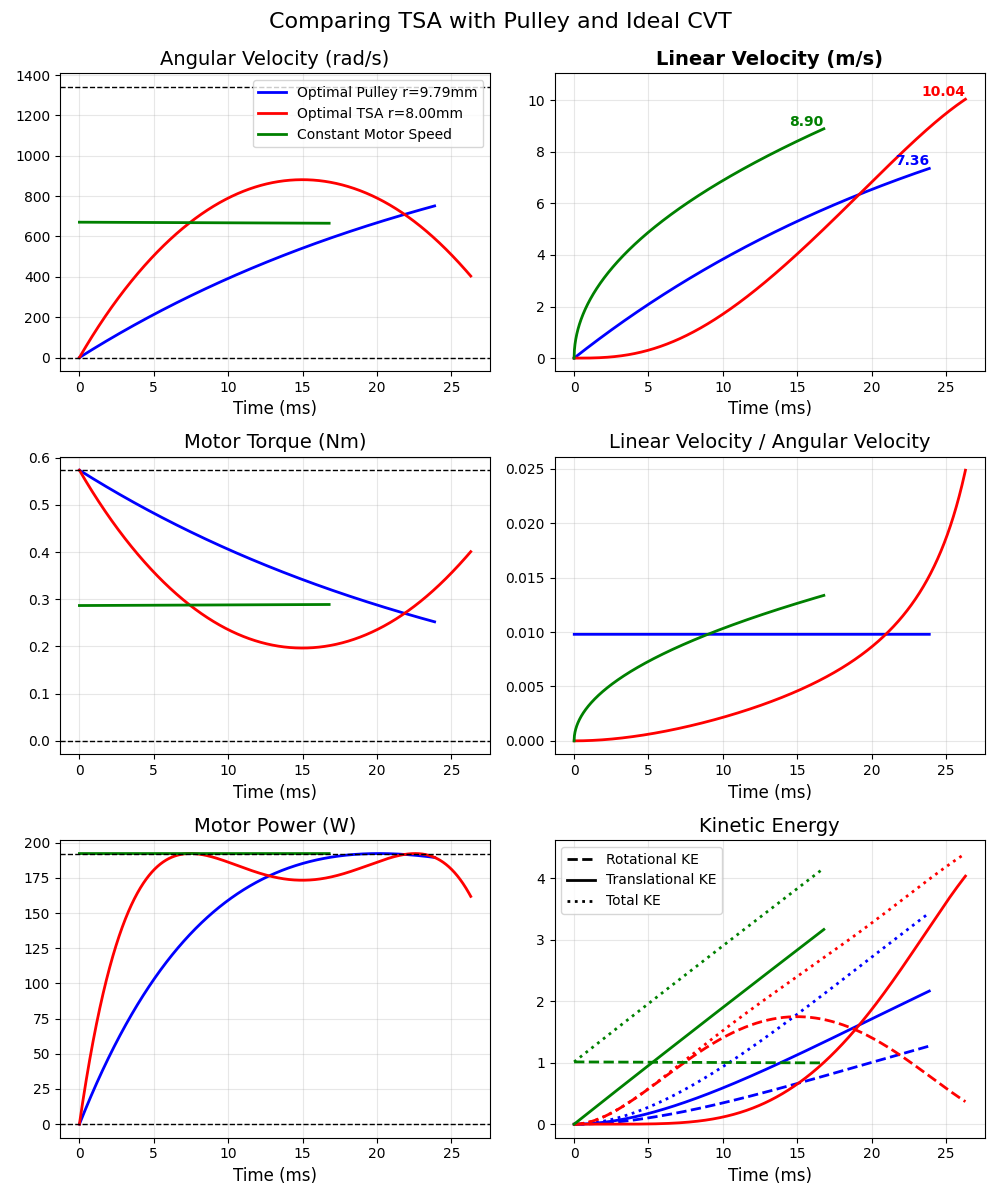

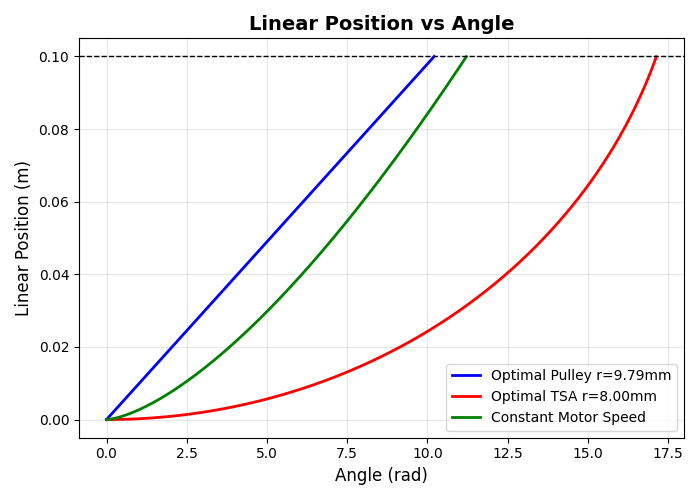

In [14]:
voltage_base = 6
params = {
    'm': 0.080, # mass
    # 'I': 0.5 * (37.4/1000/2) * (28.4/1000/2)**2,  #kg m^2
    'I': 4.5e-6,  #kg m^2
    'stroke': 0.100, # y starts from zero and stops at stroke
    # 'g': 9.81, #m/s^2
    'g': 9.81, #m/s^2
    # 'tau_max': 0.2795, #Nm
    # 'w_max': 1704, #rad/s
    'tau_max': 0.09555555556 * voltage_base, #Nm
    'w_max': 2135*2*np.pi/60 * voltage_base, #rad/s
}

# numerical CVT integration
def integrate_theta(get_y, get_tau, params, theta0=0, theta_dot0=0):

    m = params['m']
    I = params['I']
    stroke = params['stroke']
    g = params['g']
   
    def dynamics(t, state):
        theta, theta_dot = state
        
        y, dy_dtheta, d2y_dtheta2 = get_y(theta)
        tau = get_tau(theta, theta_dot, t)
        
        theta_ddot = (-theta_dot**2 * m * dy_dtheta * d2y_dtheta2 -  m*g*dy_dtheta + tau) / (I + m * (dy_dtheta)**2)
        return [theta_dot, theta_ddot]
    
    # Event function: stop when y reaches stroke
    def y_target_event(t, state):
        theta, theta_dot = state
        y, _, _ = get_y(theta)
        return y - stroke
    
    y_target_event.terminal = True  # Stop integration when event occurs
    y_target_event.direction = 0    # Trigger on both increasing and decreasing
    

    t_max = 2.0
    t_eval = np.arange(0, t_max, 0.00001)
    
    sol = solve_ivp(
        dynamics,
        t_span=(0, t_max),
        y0=[theta0, theta_dot0],
        # method='BDF',  # Can also try 'DOP853', 'Radau', 'BDF'
        method='RK45',
        max_step=5e-6,
        t_eval=t_eval,
        events=y_target_event,
        dense_output=True,
        rtol=1e-6,
        atol=1e-9,
    )
    
    t = sol.t
    theta = sol.y[0]
    theta_d = sol.y[1]
    
    y = np.zeros_like(theta)
    y_d = np.zeros_like(theta)
    tau = np.zeros_like(theta)
    for i, (th, th_d) in enumerate(zip(theta, theta_d)):
        y_val, dy_dtheta, _ = get_y(th)
        y[i] = y_val
        y_d[i] = dy_dtheta * th_d  # Chain rule: dy/dt = (dy/dtheta) * (dtheta/dt)
        tau[i] = get_tau(th, th_d, t[i])
    
    return {
        't': t,
        'theta': theta,
        'theta_d': theta_d,
        'y': y,
        'y_d': y_d,
        'tau': tau,
    }


def get_tau(theta, theta_dot, t):
    return params['tau_max']*(1 - theta_dot/params['w_max'])

r_pulley = 0.00979
def get_y_pulley(theta):
    y = r_pulley * theta
    dy_dtheta = r_pulley
    d2y_dtheta2 = 0
    return y, dy_dtheta, d2y_dtheta2
res_pulley = integrate_theta(get_y_pulley, get_tau, params)


L = 0.144
y_offset = 0.000 # L - y_offset > stroke
offset_direction = 1 # 1 for forward, -1 for backward
r = 0.008
theta_offset = offset_direction * np.sqrt(L**2 - (L - y_offset)**2) / r
def get_y_tsa(theta):
    y = L - np.sqrt(L**2 - (r*theta)**2)
    dy_dtheta =  (r**2 * theta) / np.sqrt(L**2 - (r*theta)**2)
    d2y_dtheta2 =  (r**2 * L**2) / (L**2 - (r*theta)**2)**(3/2)
    return y, dy_dtheta, d2y_dtheta2
res_tsa = integrate_theta(get_y_tsa, get_tau, params, theta0=theta_offset, theta_dot0=0)

y_offset = 0.005 # L - y_offset > stroke
offset_direction = -1 # 1 for forward, -1 for backward
theta_offset = offset_direction * np.sqrt(L**2 - (L - y_offset)**2) / r
res_tsa_prewind = integrate_theta(get_y_tsa, get_tau, params, theta0=theta_offset, theta_dot0=0)

def get_y_const_speed(theta):
    P_max = params['tau_max']*params['w_max'] / 4
    m = params['m']
    w_max = params['w_max']
    w_opt = w_max/2

    A = (2/3) * np.sqrt(2*P_max/m)

    y = A * (theta/w_opt)**(3/2)
    dy_dtheta = A * (3/2) * (theta/w_opt)**(1/2) * (1/w_opt)

    if theta > 1e-6:
        d2y_dtheta2 = A * (3/2) * (1/2) * (theta/w_opt)**(-1/2) * (1/w_opt)**2
    else:
        d2y_dtheta2 = A * (3/2) * (1/2) * (theta/w_opt+1e-6)**(-1/2) * (1/w_opt)**2
    return y, dy_dtheta, d2y_dtheta2
res_const_speed = integrate_theta(get_y_const_speed, get_tau, params, theta0=0, theta_dot0=params['w_max']/2)

transition_width = 30
clutch_r = 0.1
def get_y_clutch(theta):
    S_integral, S, Sp, Spp = logistic_step(theta, x0=60.0, transition_width=transition_width, transition_proportion=0.01)
    r = clutch_r
    y = r*S_integral
    dy_dtheta = r*S
    d2y_dtheta2 = r*Sp
    return y, dy_dtheta, d2y_dtheta2
no_torque = lambda theta, theta_dot, t: 0
# res_clutch = integrate_theta(get_y_clutch, get_tau=no_torque, params=params, theta0=0, theta_dot0=params['w_max'])
res_clutch = integrate_theta(get_y_clutch, get_tau=get_tau, params=params, theta0=0, theta_dot0=0)

transition_width = 0.1
# clutch_r = 0.015
# clutch_r = 0.0072
clutch_r = 10
# res_clutch_hard = integrate_theta(get_y_clutch, get_tau=no_torque, params=params, theta0=0, theta_dot0=params['w_max'])
res_clutch_hard = integrate_theta(get_y_clutch, get_tau=get_tau, params=params, theta0=0, theta_dot0=0)

#Plotting
if True:
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    axes = axes.flatten()

    res_all = {
        'pulley': res_pulley,
        'tsa': res_tsa,
        # 'tsa_prewind': res_tsa_prewind,
        'const_speed': res_const_speed,
        # 'clutch': res_clutch,
        # 'clutch_hard': res_clutch_hard,
    }


    colors = {
        'pulley': 'b', 
        'tsa': 'r', 
        'tsa_prewind': 'orange', 
        'const_speed': 'g', 
        'clutch': 'purple',
        'clutch_hard': 'magenta',
    }
    labels = {
        'pulley': f'Optimal Pulley r={r_pulley*1000:.2f}mm', 
        'tsa': f'Optimal TSA r={r*1000:.2f}mm', 
        'const_speed': 'Constant Motor Speed', 
        'tsa_prewind': 'TSA Prewind', 
        'clutch': 'Soft Clutch',
        'clutch_hard': 'Hard Clutch',
    }
    title = 'Comparing TSA with Pulley and Ideal CVT'
    fig.suptitle(title, fontsize=16, y=0.99)

    # # theta vs t
    # for key, res in res_all.items():
    #     axes[0].plot(res['t'], res['theta'], color=colors[key], linewidth=2, label=labels[key])
    # # axes[0].set_ylabel('Angle (rad)', fontsize=12)
    # axes[0].set_xlabel('Time (s)', fontsize=12)
    # axes[0].grid(True, alpha=0.3)
    # axes[0].set_title('Angle (rad)', fontsize=14)
    # axes[0].legend()

    # theta_dot vs t
    # Use time in milliseconds for all time plots
    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000  # convert to ms
        axes[0].plot(t_ms, res['theta_d'], color=colors[key], linewidth=2, label=labels[key])
    # axes[1].set_ylabel('Angular Velocity (rad/s)', fontsize=12)
    axes[0].set_xlabel('Time (ms)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Angular Velocity (rad/s)', fontsize=14)
    axes[0].axhline(y=0, color='k', linestyle='--', linewidth=1)
    axes[0].axhline(y=params['w_max'], color='k', linestyle='--', linewidth=1)
    axes[0].legend()

    # # y vs t
    # for key, res in res_all.items():
    #     t_ms = np.array(res['t']) * 1000
    #     axes[2].plot(t_ms, res['y'], color=colors[key], linewidth=2, label=labels[key])
    # # axes[2].set_ylabel('Linear Position (m)', fontsize=12)
    # axes[2].set_xlabel('Time (ms)', fontsize=12)
    # axes[2].grid(True, alpha=0.3)
    # axes[2].set_title('Linear Position (m)', fontsize=14)

    # y_dot vs t
    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000
        axes[1].plot(t_ms, res['y_d'], color=colors[key], linewidth=2, label=labels[key])
        # Mark the final point in y_dot vs t for each key
        final_y_d = res['y_d'][-1]
        print(f"{key}: {final_y_d:.5f}")
        axes[1].text(
            t_ms[-1],
            final_y_d,
            f"{final_y_d:.2f}",
            fontsize=10,
            color=colors[key],
            va='bottom',
            ha='right',
            fontweight='bold'
        )
        if key == 'clutch' or key == 'tsa':
            axes[1].set_ylim(None, final_y_d*1.1)
    # axes[3].set_ylabel('Linear Velocity (m/s)', fontsize=12)
    axes[1].set_xlabel('Time (ms)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('Linear Velocity (m/s)', fontsize=14, fontweight='bold')
    # axes[3].set_ylim(0, 8)


    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000
        # KE = 0.5 * I * theta_dot^2
        # Assume moment of inertia I=1 for demonstration. Replace with actual if available.
        I = params['I']
        m = params['m']
        KE_rot = 0.5 * I * np.array(res['theta_d'])**2
        KE_trans = 0.5 * m * np.array(res['y_d'])**2
        axes[5].plot(t_ms, KE_rot, color=colors[key], linestyle='--', linewidth=2, label=f"{labels[key]} Rotational")
        axes[5].plot(t_ms, KE_trans, color=colors[key], linewidth=2, label=f"{labels[key]} Translational")
        axes[5].plot(t_ms, KE_rot + KE_trans, linestyle=':', color=colors[key], linewidth=2, label=f"{labels[key]} Total")

        tau = np.array(res['tau'])        # Torque
        theta_d = np.array(res['theta_d'])  # Angular velocity
        power = tau * theta_d             # Power = torque * angular speed

        # Compute total kinetic energy = rotational + translational
        KE_rot = 0.5 * params['I'] * theta_d**2
        y_d = np.array(res['y_d'])
        KE_trans = 0.5 * params['m'] * y_d**2
        KE_total = KE_rot + KE_trans

        # Compute d(KE_total)/dt numerically
        t = np.array(res['t'])
        t_ms_local = t * 1000
        dKE_dt = np.gradient(KE_total, t)

        # Plot power (tau*theta_d)
        axes[4].plot(t_ms_local, power, color=colors[key], linewidth=2, label=labels[key])
        # Plot d(KE)/dt for comparison, dashed line
        # axes[4].plot(t_ms_local, dKE_dt, color=colors[key], linestyle='--', linewidth=3, label=f"{labels[key]} d(KE)/dt")

    # axes[4].set_ylabel('KE (J)', fontsize=12)
    axes[5].set_xlabel('Time (ms)', fontsize=12)
    axes[5].grid(True, alpha=0.3)
    axes[5].set_title('Kinetic Energy', fontsize=14)

    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Rotational KE'),
        Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Translational KE'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=2, label='Total KE'),
    ]
    axes[5].legend(handles=custom_lines, fontsize=10)
        
    # axes[5].set_ylabel('Motor Power (W)', fontsize=12)
    axes[4].set_xlabel('Time (ms)', fontsize=12)
    axes[4].grid(True, alpha=0.3)
    axes[4].set_title('Motor Power (W)', fontsize=14)
    axes[4].axhline(y=params['tau_max']*params['w_max']/4, color='k', linestyle='--', linewidth=1)
    axes[4].axhline(y=0, color='k', linestyle='--', linewidth=1)


    for key, res in res_all.items():
        t_ms = np.array(res['t']) * 1000
        y_d = np.array(res['y_d'])
        theta_d = np.array(res['theta_d'])
        ratio = np.divide(y_d, theta_d, out=np.full_like(y_d, np.nan), where=theta_d!=0)
        axes[3].plot(t_ms, ratio, color=colors[key], linewidth=2, label=labels[key])
        if key == 'clutch':
            axes[3].set_ylim(None, ratio[-1]*1.1)

        tau = np.array(res['tau'])
        axes[2].plot(t_ms, tau, color=colors[key], linewidth=2, label=labels[key])


        # Create a twin y-axis on the right for force if it doesn't exist
        # if not hasattr(axes[7], 'twin_force'):
        #     axes[7].twin_force = axes[7].twinx()
        #     axes[7].twin_force.set_ylabel('Force (N)', fontsize=12)
        #     axes[7].twin_force.grid(False)
        #     axes[7].twin_force.set_title('Motor Torque (Nm) and Linear Force (N)', fontsize=14, fontweight='bold')
        #     axes[7].twin_force.set_ylim(-0.01, 300)
        # force = tau / ratio
        # axes[7].twin_force.plot(t_ms, force, color=colors[key], linestyle=':', linewidth=2, label=labels[key])

    # axes[6].set_ylabel('Linear/Angular Velocity (m/rad)', fontsize=12)
    axes[3].set_xlabel('Time (ms)', fontsize=12)
    axes[3].grid(True, alpha=0.3)
    axes[3].set_title('Linear Velocity / Angular Velocity', fontsize=14)
        
    # axes[7].set_ylabel('Torque (Nm)', fontsize=12)
    axes[2].set_xlabel('Time (ms)', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title('Motor Torque (Nm)', fontsize=14)
    axes[2].axhline(y=params['tau_max'], color='k', linestyle='--', linewidth=1)
    axes[2].axhline(y=0, color='k', linestyle='--', linewidth=1)


    plt.tight_layout()
    plt.savefig('optimal_comparison_theta.png', dpi=300)


    plt.figure(figsize=(7, 5))
    for key, res in res_all.items():
        y_num = np.array(res['y'])
        theta_num = np.array(res['theta'])
        if key == 'tsa_prewind':
            linestyle = '--'
        else:
            linestyle = '-'
        plt.plot(theta_num, y_num, color=colors[key], linewidth=2, label=labels[key], linestyle=linestyle)
    plt.axhline(y=params['stroke'], color='k', linestyle='--', linewidth=1)
    plt.xlabel('Angle (rad)', fontsize=12)
    plt.ylabel('Linear Position (m)', fontsize=12)
    plt.title('Linear Position vs Angle', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.show()